## 2. Data Understanding

In [1]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import nltk

In [2]:
  df = pd.read_csv ("/content/Kendaraanlistrik_2025.csv")
  df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1828 entries, 0 to 1827
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      1828 non-null   int64  
 1   created_at               1828 non-null   object 
 2   favorite_count           1828 non-null   int64  
 3   full_text                1828 non-null   object 
 4   id_str                   1828 non-null   int64  
 5   image_url                614 non-null    object 
 6   in_reply_to_screen_name  728 non-null    object 
 7   lang                     1828 non-null   object 
 8   location                 0 non-null      float64
 9   quote_count              1828 non-null   int64  
 10  reply_count              1828 non-null   int64  
 11  retweet_count            1828 non-null   int64  
 12  tweet_url                1828 non-null   object 
 13  user_id_str              1828 non-null   int64  
 14  username                

In [3]:
df.isnull().sum()

,0
conversation_id_str,0
created_at,0
favorite_count,0
full_text,0
id_str,0
image_url,1214
in_reply_to_screen_name,1100
lang,0
location,1828
quote_count,0


In [4]:
df = df[['full_text','created_at','user_id_str']]
df.head()

,full_text,created_at,user_id_str
0,@Ary_PrasKe2 Masih kurang hasil dari jualan ta...,Sat May 31 22:50:10 +0000 2025,1224670930430906369
1,@CNNIndonesia Bodo AMAT Selama Minyak bumi mas...,Sat May 31 13:44:48 +0000 2025,1244476057891160064
2,@SkeptisU @AsahPolaPikir jual beli kendaraan l...,Sat May 31 12:03:50 +0000 2025,739948478760124416
3,Gubernur Bengkulu Helmi Hasan menyatakan siap ...,Sat May 31 11:03:46 +0000 2025,423220305
4,16.53 Terjadi Kecelakaan lalu lintas antara Ke...,Sat May 31 09:53:26 +0000 2025,76647722


In [5]:
df.count()

,0
full_text,1828
created_at,1828
user_id_str,1828


In [6]:
df.shape

(1828, 3)

## 3. Data Preparation

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop_duplicates(subset='full_text')

In [9]:
df.shape

(1800, 3)

In [10]:
# mengganti nama kolom
df = df.rename(columns={'created_at': 'tanggal', 'full_text': 'text', 'user_id_str': 'id_pengguna' })
df.head()

,text,tanggal,id_pengguna
0,@Ary_PrasKe2 Masih kurang hasil dari jualan ta...,Sat May 31 22:50:10 +0000 2025,1224670930430906369
1,@CNNIndonesia Bodo AMAT Selama Minyak bumi mas...,Sat May 31 13:44:48 +0000 2025,1244476057891160064
2,@SkeptisU @AsahPolaPikir jual beli kendaraan l...,Sat May 31 12:03:50 +0000 2025,739948478760124416
3,Gubernur Bengkulu Helmi Hasan menyatakan siap ...,Sat May 31 11:03:46 +0000 2025,423220305
4,16.53 Terjadi Kecelakaan lalu lintas antara Ke...,Sat May 31 09:53:26 +0000 2025,76647722


In [11]:
def clean_twitter_text(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text) #fungsi ini untuk menghapus mention
    text = re.sub(r'#\w+', '', text)  #fungsi ini untuk menghapus hashtag
    text = re.sub(r'RT[\s]+', '', text) #fungsi ini untuk menghapus retweet
    text = re.sub(r'https?://\S+', '', text)  #fungsi ini untuk menghapus url
    text = re.sub(r'[^A-Za-z0-9 ]', '', text) #fungsi ini untuk menghapus alfanumerik
    text = re.sub(r'\s+', ' ', text).strip()  #fungsi ini untuk menghapus spasi yang berlebihan

    return text

In [12]:
# case folding
df['text'] = df ['text'].str.lower()

In [13]:
df['clean_text'] = df['text'].apply(clean_twitter_text)
df.head()

,text,tanggal,id_pengguna,clean_text
0,@ary_praske2 masih kurang hasil dari jualan ta...,Sat May 31 22:50:10 +0000 2025,1224670930430906369,masih kurang hasil dari jualan tambang kendara...
1,@cnnindonesia bodo amat selama minyak bumi mas...,Sat May 31 13:44:48 +0000 2025,1244476057891160064,bodo amat selama minyak bumi masih ada omong k...
2,@skeptisu @asahpolapikir jual beli kendaraan l...,Sat May 31 12:03:50 +0000 2025,739948478760124416,jual beli kendaraan listrik copotan apa sih yg...
3,gubernur bengkulu helmi hasan menyatakan siap ...,Sat May 31 11:03:46 +0000 2025,423220305,gubernur bengkulu helmi hasan menyatakan siap ...
4,16.53 terjadi kecelakaan lalu lintas antara ke...,Sat May 31 09:53:26 +0000 2025,76647722,1653 terjadi kecelakaan lalu lintas antara ken...


In [14]:
df[['clean_text']].to_csv('Data_bersih.csv', index=False)

In [15]:
df['clean_text_awal'] = df['text'].apply(clean_twitter_text)

In [16]:
#  Normalisasi
norm = { 'bodo amat': 'gak peduli','copotan': 'part bekas',' kendara ':' kendaraan ',' yg ':' yang ', ' udh ':' udah ', ' jl ':' jalan ',' ia ':' dia ',' copotan ': ' part bekas ',' min ':' kak ', ' ortu ':' orang tua ',' malem ':' malam', ' malem2 ':' malam ', ' sm ':' sama ', ' dy ':' dia ', ' lg ':' lagi ', ' skrg ':' sekarang ', ' ddpn ':' didepan ', ' makasi ':' makasih ', ' pertamaz ':' pertamax ', ' jg ':' juga ', ' donk ':' dong ', ' ikutann ':' ikutan ', ' banyakk ':' banyak ', ' twt ':' tweet', 'mantaap ':'mantap ', ' juarak':' juara ', 'daridulu ':'dari dulu ', 'siapp ':'siap ', ' gamau ':' tidak mau ', ' sll ':' selalu ', ' qu ':' aku ', ' krn ':' karena ', ' irii':' iri', ' muluu ':' terus ', 'mada ':'masa ', 'jgn ':'jangan ', ' jgn ':' jangan ', ' muluuu ':' terus ', 'ntar ':'nanti ', ' awtnya':' awetnya', 'gg ':'keren ', ' kerennn':' keren ', ' bisaa ':' bisa ', 'gaaa':'tidak ', " yg ": " yang ", ' nyampe':' sampai', ' nyampe ':' sampai ', ' lu ':' kamu ', ' ikhlaaasss ':' ikhlas ', ' gak ':' tidak ', ' klo ':' kalo ', ' amp ': ' sampai ', ' ga ':' tidak ', ' yaaaa':' ya ', 'betolll ':'betul ', ' kaga ':' tidak ', ' idk ':' tidak tahu ', ' jkt ':' jakarta ', ' lo ':' kamu ', ' bjir ':' ', ' kek ':' seperti ', ' yg ':' yang ', ' utk ':' untuk ', 'kismin ':'miskin ', ' kismin ':' miskin ', ' pd ':' pada ', ' dgn ':' dengan ', ' ituu ':' itu ', ' jg ':' juga ', 'yoi':'iya ', ' yoi ':' iya ', 'org2 ':'orang ', ' tak ':' tidak ', ' kyk ':' seperti ', ' sbg ':' sebagai ', ' anjjjj ':' ', ' bgt ':' banget ', 'km ':'kamu ', ' km ':' kamu', ' byk ':' banyak ', ' lg ':' lagi ', ' mrk ':' mereka ', ' blm ':' belum '}

def normalisasi(str_text):
  for i in norm:
    str_text = str_text.replace(i, norm[i])
  return str_text

df['clean_text'] = df['clean_text'].apply(lambda x: normalisasi(x))
df

,text,tanggal,id_pengguna,clean_text,clean_text_awal
0,@ary_praske2 masih kurang hasil dari jualan ta...,Sat May 31 22:50:10 +0000 2025,1224670930430906369,masih kurang hasil dari jualan tambang kendara...,masih kurang hasil dari jualan tambang kendara...
1,@cnnindonesia bodo amat selama minyak bumi mas...,Sat May 31 13:44:48 +0000 2025,1244476057891160064,gak peduli selama minyak bumi masih ada omong ...,bodo amat selama minyak bumi masih ada omong k...
2,@skeptisu @asahpolapikir jual beli kendaraan l...,Sat May 31 12:03:50 +0000 2025,739948478760124416,jual beli kendaraan listrik part bekas apa sih...,jual beli kendaraan listrik copotan apa sih yg...
3,gubernur bengkulu helmi hasan menyatakan siap ...,Sat May 31 11:03:46 +0000 2025,423220305,gubernur bengkulu helmi hasan menyatakan siap ...,gubernur bengkulu helmi hasan menyatakan siap ...
4,16.53 terjadi kecelakaan lalu lintas antara ke...,Sat May 31 09:53:26 +0000 2025,76647722,1653 terjadi kecelakaan lalu lintas antara ken...,1653 terjadi kecelakaan lalu lintas antara ken...
...,...,...,...,...,...
1823,keberhasilan ini menegaskan komitmen kami dala...,Tue Mar 25 07:33:49 +0000 2025,1466650975364546563,keberhasilan ini menegaskan komitmen kami dala...,keberhasilan ini menegaskan komitmen kami dala...
1824,perjalanan mudik dengan mobil listrik? tenang ...,Tue Mar 25 07:25:37 +0000 2025,240527619,perjalanan mudik dengan mobil listrik tenang c...,perjalanan mudik dengan mobil listrik tenang c...
1825,dengan 307 spklu tersebar di wilayah jawa teng...,Tue Mar 25 07:24:13 +0000 2025,570498779,dengan 307 spklu tersebar di wilayah jawa teng...,dengan 307 spklu tersebar di wilayah jawa teng...
1826,darmawan prasodjo beserta jajaran meninjau lan...,Tue Mar 25 07:24:13 +0000 2025,570498779,darmawan prasodjo beserta jajaran meninjau lan...,darmawan prasodjo beserta jajaran meninjau lan...


In [17]:
# Tokenize
import re
tokenized = df['clean_text'].apply(lambda x: re.findall(r'\w+', x.lower()))

In [18]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.8 MB/s eta 0:00:00


In [19]:
# Stopwords
import Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory, StopWordRemover, ArrayDictionary
more_stop_words = []

stop_words = StopWordRemoverFactory().get_stop_words()
stop_words.extend(more_stop_words)

new_array = ArrayDictionary(stop_words)
stop_words_remover_new = StopWordRemover(new_array)

def stopword(str_text):
  str_text = stop_words_remover_new.remove(str_text)
  return str_text

df['clean_text'] = df['clean_text'].apply(lambda x: stopword(x))
df.head()

,text,tanggal,id_pengguna,clean_text,clean_text_awal
0,@ary_praske2 masih kurang hasil dari jualan ta...,Sat May 31 22:50:10 +0000 2025,1224670930430906369,kurang hasil jualan tambang kendaraan listrik,masih kurang hasil dari jualan tambang kendara...
1,@cnnindonesia bodo amat selama minyak bumi mas...,Sat May 31 13:44:48 +0000 2025,1244476057891160064,gak peduli selama minyak bumi ada omong kosong...,bodo amat selama minyak bumi masih ada omong k...
2,@skeptisu @asahpolapikir jual beli kendaraan l...,Sat May 31 12:03:50 +0000 2025,739948478760124416,jual beli kendaraan listrik part bekas apa sih...,jual beli kendaraan listrik copotan apa sih yg...
3,gubernur bengkulu helmi hasan menyatakan siap ...,Sat May 31 11:03:46 +0000 2025,423220305,gubernur bengkulu helmi hasan menyatakan siap ...,gubernur bengkulu helmi hasan menyatakan siap ...
4,16.53 terjadi kecelakaan lalu lintas antara ke...,Sat May 31 09:53:26 +0000 2025,76647722,1653 terjadi kecelakaan lalu lintas kendaraan ...,1653 terjadi kecelakaan lalu lintas antara ken...


In [20]:
# Stemming
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

tokenized = df['clean_text'].apply(lambda x: x.split())

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(text_cleaning):
  do = []
  for w in text_cleaning:
    dt = stemmer.stem(w)
    do.append(dt)
  d_clean = []
  d_clean = " ".join(do)
  print(d_clean)
  return d_clean

tokenized = tokenized.apply(stemming)

df.to_csv("/content/hasilPreprocessingKendaraanListrik.csv", index=False)

kurang hasil jual tambang kendara listrik
gak peduli lama minyak bumi ada omong kosong kendara listrik
jual beli kendara listrik part bekas apa sih tidak
gubernur bengkulu helm hasan nyata siap kucur anggar bantu siswa sekolah tengah juru smk tempat kembang kendara listrik hasil teliti jadi produk komersial bisa jual pasar
1653 jadi celaka lalu lintas kendara sepeda motor kendara mobil listrik taksi online jalan medan merdeka selatan jakpus arah jalan budi mulia titik kenal depan kantor pt danareksa saat sedang tangan tugas
dorong tumbuh industri kendara listrik danantara indonesia resmi mitra eramet
trip planner pln mobile fitur keren bantu kamu temu spklu panjang rute libur perlu khawatir habis daya road trip pakai kendara listrik
motor mobil part bekas mungkin ilegal semua kendara jd tenaga listrik di desain kompak alat elektronik beberapa tahun pakai hanya daur ulang
33 sumur dangkal 31 henry sanderson jurnalis financial times tulis volt rush the winners and losers in the race to g

In [21]:
data = pd.read_csv("/content/hasilPreprocessingKendaraanListrik.csv", encoding='latin1')
clean_df = data.copy()

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

In [23]:
import requests

# Inisialisasi kamus
lexicon_positive = {}
lexicon_negative = {}

# --- Muat Lexicon Positif ---
url_pos = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
response = requests.get(url_pos)
if response.status_code == 200:
    lines = response.text.strip().split('\n')[1:]  # Lewati header
    for line in lines:
        if line.strip():
            word, score = line.strip().split('\t')
            lexicon_positive[word.lower()] = int(score)
else:
    print("Gagal mengambil lexicon positif")

# --- Muat Lexicon Negatif ---
url_neg = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"
response = requests.get(url_neg)
if response.status_code == 200:
    lines = response.text.strip().split('\n')[1:]  # Lewati header
    for line in lines:
        if line.strip():
            word, score = line.strip().split('\t')
            lexicon_negative[word.lower()] = int(score)
else:
    print("Gagal mengambil lexicon negatif")

In [24]:
def sentiment_analysis_lexicon_indonesia(text):
    score = 0

    for word in text.split():
        if word in lexicon_positive:
            score += lexicon_positive[word]
        if word in lexicon_negative:
            score += lexicon_negative[word]

    if score > 0:
        polarity = 'positive'
    elif score < 0:
        polarity = 'negative'
    else:
        polarity = 'positive'

    return score, polarity

In [25]:
# 1. Terapkan fungsi ke kolom clean_text
results = clean_df['clean_text'].apply(sentiment_analysis_lexicon_indonesia)

# 2. Pecah hasil menjadi dua kolom
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]


print(clean_df['polarity'].value_counts())

polarity
positive    951
negative    849
Name: count, dtype: int64


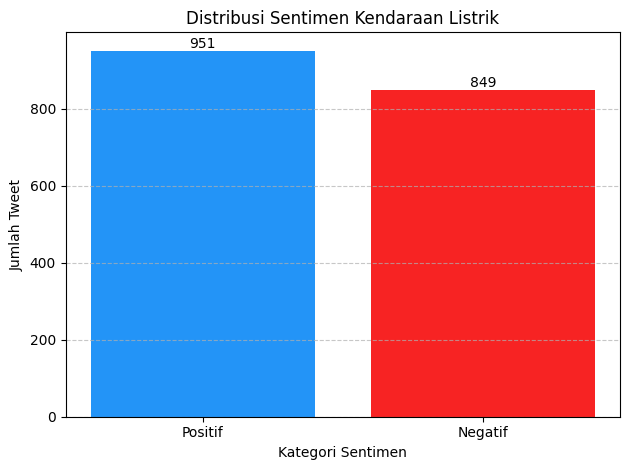

In [26]:
import matplotlib.pyplot as plt

# === Hitung total masing-masing sentimen ===
total_positif = clean_df['polarity'].value_counts().get('positive', 0)
total_negatif = clean_df['polarity'].value_counts().get('negative', 0)

# === Label dan nilai untuk diagram batang ===
labels = ['Positif', 'Negatif']
counts = [total_positif, total_negatif]

# === Membuat diagram batang (bar chart) ===
bars = plt.bar(labels, counts, color=['#2394f7', '#f72323'])

# === Menambahkan nilai ke atas setiap batang ===
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height(),
             str(int(bar.get_height())),
             ha='center', va='bottom')

# === Judul visualisasi ===
plt.title('Distribusi Sentimen Kendaraan Listrik')
plt.ylabel('Jumlah Tweet')
plt.xlabel('Kategori Sentimen')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4.Modeling


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
X = clean_df['clean_text']
y = clean_df['polarity']

In [29]:
# === Split data ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
# === TF-IDF Vectorizer ===
tfidfVectorizer = TfidfVectorizer()
tfidf_train = tfidfVectorizer.fit_transform(X_train)
tfidf_test = tfidfVectorizer.transform(X_test)

print(tfidf_train.shape)
print(tfidf_test.shape)

(1440, 6018)
(360, 6018)


In [31]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(tfidf_train, y_train)

MultinomialNB()

In [32]:
y_pred = model.predict(tfidf_test)

## 5.**Evaluation**


Hasil Confusion Matrix:
[[102  68]
 [ 26 164]]


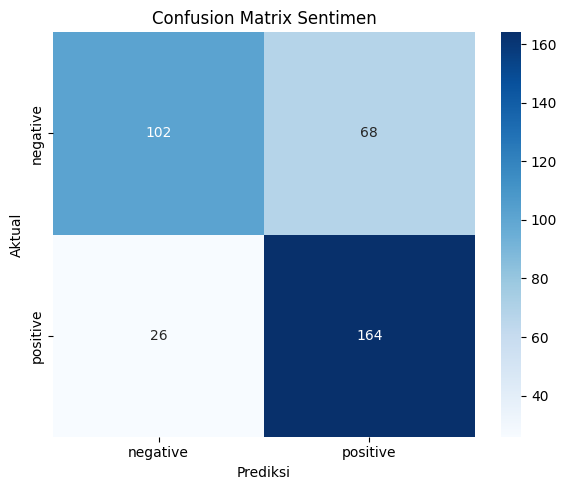

In [33]:
# === Confusion Matrix ===
print("\nHasil Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# === Visualisasi Confusion Matrix ===
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Sentimen')
plt.tight_layout()
plt.show()

In [34]:
# === Accuracy Score ===
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {accuracy:.4f}")

# === Classification Report ===
print("\nLaporan Klasifikasi:\n")
print(classification_report(y_test, y_pred))


Accuracy Score: 0.7389

Laporan Klasifikasi:

              precision    recall  f1-score   support

    negative       0.80      0.60      0.68       170
    positive       0.71      0.86      0.78       190

    accuracy                           0.74       360
   macro avg       0.75      0.73      0.73       360
weighted avg       0.75      0.74      0.73       360



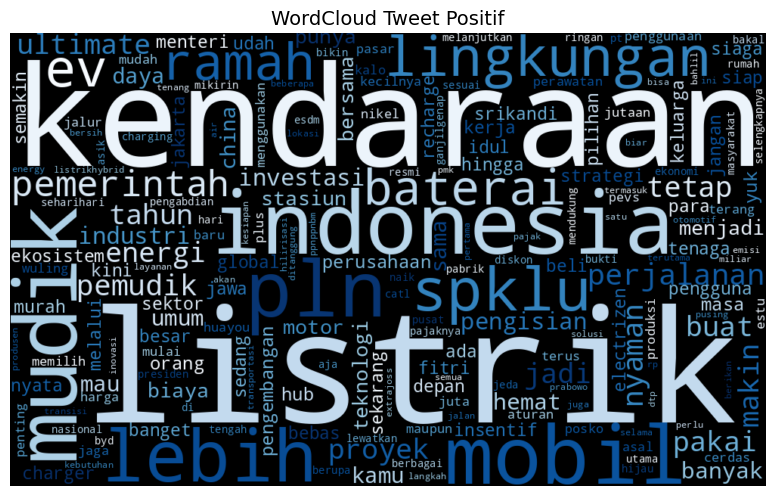

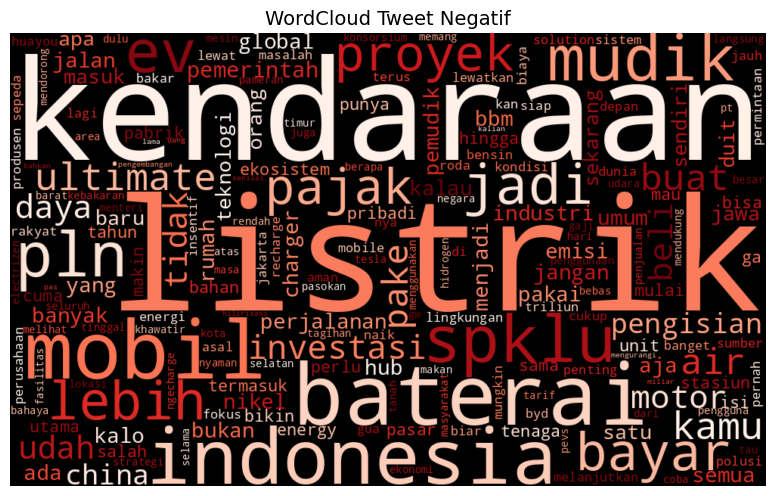

In [35]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# === Fungsi untuk membuat WordCloud ===
def plot_cloud(text, title, colormap):
    wordcloud = WordCloud(
        width=1000,          # Ukuran lebar dikurangi
        height=600,          # Ukuran tinggi dikurangi
        background_color='black',
        stopwords=STOPWORDS,
        colormap=colormap,
        collocations=False
    ).generate(text)

    plt.figure(figsize=(8, 5))  # Ukuran figur lebih kecil
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# === Pisahkan tweet berdasarkan sentimen ===
positif_tweets = clean_df[clean_df['polarity'] == 'positive']['clean_text']
negatif_tweets = clean_df[clean_df['polarity'] == 'negative']['clean_text']

# === Gabungkan teks menjadi satu string untuk masing-masing sentimen ===
all_positif = ' '.join(positif_tweets.dropna().astype(str))
all_negatif = ' '.join(negatif_tweets.dropna().astype(str))

# === WordCloud untuk Tweet Positif ===
plot_cloud(all_positif, "WordCloud Tweet Positif", "Blues")

# === WordCloud untuk Tweet Negatif ===
plot_cloud(all_negatif, "WordCloud Tweet Negatif", "Reds")

# 6.Deployment

In [42]:
# TF-IDF transform untuk data baru
tfidf_data = tfidfVectorizer.transform(data['clean_text'])

# Prediksi label sentimen
data['polarity'] = model.predict(tfidf_data)

In [43]:
# Hitung total masing-masing sentimen
total_positif = clean_df[clean_df['polarity'] == 'positive'].shape[0]
total_negatif = clean_df[clean_df['polarity'] == 'negative'].shape[0]

# Simpan ke file teks
with open("ringkasan_sentimen.txt", "w", encoding='utf-8') as f:
    f.write("Ringkasan Sentimen Kendaraan Listrik:\n")
    f.write(f"Positif : {total_positif}\n")
    f.write(f"Negatif : {total_negatif}\n")

In [44]:
data.to_csv("hasil_analisis_sentimen.csv", index=False)
print("Hasil analisis telah disimpan ke 'hasil_analisis_sentimen.csv'")

Hasil analisis telah disimpan ke 'hasil_analisis_sentimen.csv'
